In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [62]:
import numpy as np
import pandas as pd

In [63]:
# LOAD DATA

price_data = pd.read_csv("/kaggle/input/datasets/rabia1zulfiqar/ubl-psx/UBL.csv")


fundamental_data = pd.read_csv(
    "/kaggle/input/datasets/rabia1zulfiqar/ubl-psx/UBL_fundamental_features.csv",
    na_values=["-", "--", ""]
)

In [64]:
fundamental_data = fundamental_data.rename(columns={
    "Unnamed: 0": "QUARTER",
    "Unnamed: 1": "DATE"
})

fundamental_data["DATE"] = pd.to_datetime(
    fundamental_data["DATE"].str.extract(r"([A-Z][a-z]{2} \d{2}, \d{4})")[0]
)

In [65]:
# PRICE DATA

# Convert date
price_data["DATE"] = pd.to_datetime(price_data["DATE"])

# Select 5 years
price_data_5yr = price_data[
    price_data["DATE"] >= pd.Timestamp("2021-01-01")
].copy()

In [66]:
# ==========================================
# 1. MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(price_data_5yr.isnull().sum())


# ==========================================
# 2. EXACT DUPLICATES
# ==========================================

duplicate_rows = price_data_5yr[
    price_data_5yr.duplicated(keep=False)
]

print("\nExact Duplicate Rows:")
print(duplicate_rows)


Missing Values:
DATE      0
OPEN      0
HIGH      0
LOW       0
CLOSE     0
VOLUME    0
CHANGE    0
dtype: int64

Exact Duplicate Rows:
           DATE    OPEN   HIGH    LOW   CLOSE  VOLUME  CHANGE
1940 2024-05-08  196.96  197.0  193.7  194.97  538672   -1.46
1941 2024-05-08  196.96  197.0  193.7  194.97  538672   -1.46


In [67]:
# Remove exact duplicates
price_data_5yr = price_data_5yr.drop_duplicates()

In [68]:
# ==========================================
# 3. VALIDATE PRICE VALUES
# ==========================================

valid_price = (
    (price_data_5yr["OPEN"] > 0) &
    (price_data_5yr["HIGH"] > 0) &
    (price_data_5yr["LOW"] > 0) &
    (price_data_5yr["CLOSE"] > 0) &
    (price_data_5yr["VOLUME"] >= 0) &
    (price_data_5yr["HIGH"] >= price_data_5yr["OPEN"]) &
    (price_data_5yr["HIGH"] >= price_data_5yr["CLOSE"]) &
    (price_data_5yr["HIGH"] >= price_data_5yr["LOW"]) &
    (price_data_5yr["LOW"] <= price_data_5yr["OPEN"]) &
    (price_data_5yr["LOW"] <= price_data_5yr["CLOSE"])
)

invalid_price_rows = price_data_5yr[~valid_price]

print("\nInvalid Price Records:")
print(invalid_price_rows)


Invalid Price Records:
           DATE  OPEN   HIGH    LOW   CLOSE  VOLUME  CHANGE
2034 2024-09-26   0.0  338.0  338.0  297.73      99     0.0


In [69]:
# Remove invalid records
price_data_5yr = price_data_5yr[valid_price].copy()

In [70]:
# ==========================================
# 4. CHECK DUPLICATE DATES AGAIN
# ==========================================

duplicate_dates = price_data_5yr[
    price_data_5yr["DATE"].duplicated(keep=False)
]

print("\nRemaining Duplicate Dates:")
print(duplicate_dates)


Remaining Duplicate Dates:
Empty DataFrame
Columns: [DATE, OPEN, HIGH, LOW, CLOSE, VOLUME, CHANGE]
Index: []


In [71]:
# ==========================================
# 5. FINAL CHECK
# ==========================================

print("\nFinal Shape:", price_data_5yr.shape)
print("Exact Duplicates:", price_data_5yr.duplicated().sum())
print("Duplicate Dates:", price_data_5yr["DATE"].duplicated().sum())


Final Shape: (1358, 7)
Exact Duplicates: 0
Duplicate Dates: 0


In [72]:
# FUNDAMENTALS

print("\nFundamental Data:")
print(fundamental_data.head())

print("\nShape:", fundamental_data.shape)
print("\nMissing Values:")
print(fundamental_data.isnull().sum())

print("\nRows containing missing values:")
print(
    fundamental_data[
        fundamental_data.isnull().any(axis=1)
    ].to_string(index=False)
)


Fundamental Data:
   QUARTER       DATE   Revenue Revenue Growth (YoY)  Net Income  \
0  Q2 2026 2026-06-30  124453.0               13.44%     37480.0   
1  Q1 2026 2026-03-31  143268.0               39.56%     48417.0   
2  Q4 2025 2025-12-31  109489.0               34.77%     29922.0   
3  Q3 2025 2025-09-30  107054.0               59.62%     35355.0   
4  Q2 2025 2025-06-30  109713.0                  NaN     28616.0   

  Net Income Growth  EPS (Basic)  EPS (Diluted) EPS Growth  Total Assets  \
0            30.98%        14.97          14.97     30.97%      15153684   
1            34.09%        19.33          19.33     31.80%      12732073   
2            14.89%        11.95          11.95     12.32%      12628515   
3            93.00%        14.12          14.12     88.77%      11281408   
4               NaN        11.43          11.43        NaN      11095530   

   Cash & Equivalents  
0              589053  
1              482245  
2              396150  
3              3896

In [73]:
fundamental_data = fundamental_data.sort_values("DATE").reset_index(drop=True)

In [74]:
# ============================================================
# MISSING VALUE HANDLING
# ============================================================

# ------------------------------------------------------------
# STEP 1: Calculate derivable YoY growth fields
# ------------------------------------------------------------

# Since data is quarterly, 4 quarters = 1 year
fundamental_data["Revenue Growth (YoY)"] = (
    fundamental_data["Revenue Growth (YoY)"]
    .fillna(
        fundamental_data["Revenue"].pct_change(4) * 100
    )
)

fundamental_data["Net Income Growth"] = (
    fundamental_data["Net Income Growth"]
    .fillna(
        fundamental_data["Net Income"].pct_change(4) * 100
    )
)

fundamental_data["EPS Growth"] = (
    fundamental_data["EPS Growth"]
    .fillna(
        fundamental_data["EPS (Basic)"].pct_change(4) * 100
    )
)


# ------------------------------------------------------------
# STEP 2: Fill missing raw fundamental values
#         using previous 4 quarters
# ------------------------------------------------------------

raw_fundamental_cols = [
    "Revenue",
    "Net Income",
    "EPS (Basic)",
    "EPS (Diluted)"
]

for col in raw_fundamental_cols:

    # Previous 4 quarters only
    rolling_mean = (
        fundamental_data[col]
        .shift(1)
        .rolling(window=4, min_periods=2)
        .mean()
    )

    fundamental_data[col] = (
        fundamental_data[col]
        .fillna(rolling_mean)
    )


/tmp/ipykernel_49/2764982227.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fundamental_data["Revenue"].pct_change(4) * 100
/tmp/ipykernel_49/2764982227.py:20: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fundamental_data["Net Income"].pct_change(4) * 100
/tmp/ipykernel_49/2764982227.py:27: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fundamental_data["EPS (Basic)"].pct_change(4) * 100


In [75]:
# ------------------------------------------------------------
# STEP 3: Recalculate derived growth fields
#         after raw values have been filled
# ------------------------------------------------------------

fundamental_data["Revenue Growth (YoY)"] = (
    fundamental_data["Revenue Growth (YoY)"]
    .fillna(
        fundamental_data["Revenue"].pct_change(4) * 100
    )
)

fundamental_data["Net Income Growth"] = (
    fundamental_data["Net Income Growth"]
    .fillna(
        fundamental_data["Net Income"].pct_change(4) * 100
    )
)

fundamental_data["EPS Growth"] = (
    fundamental_data["EPS Growth"]
    .fillna(
        fundamental_data["EPS (Basic)"].pct_change(4) * 100
    )
)

In [76]:
# ------------------------------------------------------------
# STEP 4: Check what is STILL missing
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES AFTER AUTOMATIC IMPUTATION")
print("=" * 60)

print(fundamental_data.isnull().sum())


print("\nRows still containing missing values:")

remaining_missing = fundamental_data[
    fundamental_data.isnull().any(axis=1)
]

if remaining_missing.empty:
    print("No missing values remaining.")
else:
    print(remaining_missing.to_string(index=False))


MISSING VALUES AFTER AUTOMATIC IMPUTATION
QUARTER                 0
DATE                    0
Revenue                 0
Revenue Growth (YoY)    0
Net Income              0
Net Income Growth       0
EPS (Basic)             0
EPS (Diluted)           0
EPS Growth              0
Total Assets            0
Cash & Equivalents      0
dtype: int64

Rows still containing missing values:
No missing values remaining.


In [77]:
fundamental_data.head()

,QUARTER,DATE,Revenue,Revenue Growth (YoY),Net Income,Net Income Growth,EPS (Basic),EPS (Diluted),EPS Growth,Total Assets,Cash & Equivalents
0,Q3 2021,2021-09-30,25917.0,38.78%,6756.0,43.12%,2.76,2.76,43.00%,2680361,266604
1,Q4 2021,2021-12-31,26303.0,30.42%,8665.0,64.39%,3.54,3.54,64.39%,2781228,258071
2,Q1 2022,2022-03-31,28805.0,23.18%,9304.0,22.44%,3.80,3.80,22.44%,2481044,157403
3,Q2 2022,2022-06-30,32452.0,31.36%,2654.0,-64.08%,1.08,1.08,-64.07%,3053248,156991
4,Q3 2022,2022-09-30,31644.0,22.10%,6514.0,-3.58%,2.66,2.66,-3.62%,2917192,135887


In [78]:
# ==========================================
# ALIGN FUNDAMENTALS WITH DAILY PRICE DATA
# ==========================================

# ==========================================
# ALIGN DATE RANGES FIRST
# ==========================================

# Sort by date
price_data_5yr = price_data_5yr.sort_values("DATE").reset_index(drop=True)
fundamental_data = fundamental_data.sort_values("DATE").reset_index(drop=True)

# Find common date range
start_date = max(
    price_data_5yr["DATE"].min(),
    fundamental_data["DATE"].min()
)

end_date = min(
    price_data_5yr["DATE"].max(),
    fundamental_data["DATE"].max()
)

print("Common Date Range:")
print(start_date, "to", end_date)

Common Date Range:
2021-09-30 00:00:00 to 2026-06-30 00:00:00


In [79]:
# Restrict both datasets to common range
price_aligned = price_data_5yr[
    (price_data_5yr["DATE"] >= start_date) &
    (price_data_5yr["DATE"] <= end_date)
].copy()

fundamental_aligned = fundamental_data[
    (fundamental_data["DATE"] >= start_date) &
    (fundamental_data["DATE"] <= end_date)
].copy()

print("\nPrice data after date alignment:")
print(price_aligned.shape)

print("\nFundamental data after date alignment:")
print(fundamental_aligned.shape)


Price data after date alignment:
(1176, 7)

Fundamental data after date alignment:
(20, 11)


In [82]:
# ==========================================
# MERGE QUARTERLY FUNDAMENTALS WITH DAILY PRICE
# ==========================================

aligned_data = pd.merge_asof(
    price_aligned,
    fundamental_aligned,
    on="DATE",
    direction="backward"
)

print("\nAligned Data:")
print(aligned_data.head())

print("\nShape:", aligned_data.shape)

print("\nMissing Values:")
print(aligned_data.isnull().sum())


Aligned Data:
        DATE    OPEN    HIGH     LOW   CLOSE   VOLUME  CHANGE  QUARTER  \
0 2021-09-30  117.33  119.00  116.00  118.56  2127141    1.41  Q3 2021   
1 2021-10-01  118.00  119.45  117.05  117.83   506091   -0.73  Q3 2021   
2 2021-10-04  115.15  118.95  115.15  118.37   756631    0.54  Q3 2021   
3 2021-10-05  118.50  120.68  117.50  120.01  1526238    1.64  Q3 2021   
4 2021-10-06  120.90  122.49  119.00  121.92  1925997    1.91  Q3 2021   

   Revenue Revenue Growth (YoY)  Net Income Net Income Growth  EPS (Basic)  \
0  25917.0               38.78%      6756.0            43.12%         2.76   
1  25917.0               38.78%      6756.0            43.12%         2.76   
2  25917.0               38.78%      6756.0            43.12%         2.76   
3  25917.0               38.78%      6756.0            43.12%         2.76   
4  25917.0               38.78%      6756.0            43.12%         2.76   

   EPS (Diluted) EPS Growth  Total Assets  Cash & Equivalents  
0      

In [81]:
print(aligned_data.columns)

Index(['DATE', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME', 'CHANGE', 'QUARTER',
       'Revenue', 'Revenue Growth (YoY)', 'Net Income', 'Net Income Growth',
       'EPS (Basic)', 'EPS (Diluted)', 'EPS Growth', 'Total Assets',
       'Cash & Equivalents'],
      dtype='object')


In [83]:
# ==========================================
# CONVERT PERCENTAGE COLUMNS TO NUMERIC
# ==========================================

percentage_cols = [
    "Revenue Growth (YoY)",
    "Net Income Growth",
    "EPS Growth"
]

for col in percentage_cols:
    aligned_data[col] = pd.to_numeric(
        aligned_data[col]
        .astype(str)
        .str.replace("%", "", regex=False),
        errors="coerce"
    )

In [84]:
# ==========================================
# FUNDAMENTALS-ONLY BASELINE
# ==========================================

feature_cols = [
    "Revenue",
    "Revenue Growth (YoY)",
    "Net Income",
    "Net Income Growth",
    "EPS (Basic)",
    "EPS (Diluted)",
    "EPS Growth",
    "Total Assets",
    "Cash & Equivalents"
]

target_col = "CLOSE"

X = aligned_data[feature_cols].copy()
y = aligned_data[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1176, 9)
y shape: (1176,)


In [85]:
import random

# ========================================================
# REPRODUCIBILITY
# ========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [86]:
# ==========================================
# 1. NEXT-DAY TARGET (FUNDAMENTALS-ONLY INPUTS)
# ==========================================
df = aligned_data.sort_values("DATE").reset_index(drop=True).copy()

# Target = next trading day's close
df["next_close"] = df["CLOSE"].shift(-1)

# Date being predicted
df["tdate"] = df["DATE"].shift(-1)

# Next-day log return
df["target_ret"] = np.log(
    df["next_close"] / df["CLOSE"]
)

# Remove rows with missing target/features
df = df.dropna(
    subset=["next_close"] + feature_cols
).reset_index(drop=True)

In [87]:
# ==========================================
# 2. INPUTS AND TARGETS
# ==========================================

X = df[feature_cols]

# Next-day closing price
y_price = df["next_close"]

# Next-day log return
y_return = df["target_ret"]

# Today's close
# Used only for converting predicted return → price
# NOT used as an MLP input
current_close = df["CLOSE"]

target_dates = pd.to_datetime(df["tdate"])

In [88]:
# ==========================================
# 3. CHRONOLOGICAL TRAIN / VAL / TEST SPLIT
# ==========================================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_price_train = y_price.iloc[:train_end]
y_price_val   = y_price.iloc[train_end:val_end]
y_price_test  = y_price.iloc[val_end:]

y_return_train = y_return.iloc[:train_end]
y_return_val   = y_return.iloc[train_end:val_end]
y_return_test  = y_return.iloc[val_end:]

current_close_test = current_close.iloc[val_end:]

print("\nDataset Split:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nDate Ranges:")
print(
    "Train:",
    df["DATE"].iloc[0],
    "to",
    df["DATE"].iloc[train_end - 1]
)

print(
    "Validation:",
    df["DATE"].iloc[train_end],
    "to",
    df["DATE"].iloc[val_end - 1]
)

print(
    "Test:",
    df["DATE"].iloc[val_end],
    "to",
    df["DATE"].iloc[-1]
)


Dataset Split:
Train: (822, 9)
Validation: (176, 9)
Test: (177, 9)

Date Ranges:
Train: 2021-09-30 00:00:00 to 2025-01-22 00:00:00
Validation: 2025-01-23 00:00:00 to 2025-10-09 00:00:00
Test: 2025-10-10 00:00:00 to 2026-06-29 00:00:00


In [89]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# 4. FEATURE SCALING
# ==========================================

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

# Scale target using training data only
scaler_y_price = StandardScaler()

y_price_train_scaled = scaler_y_price.fit_transform(
    y_price_train.values.reshape(-1, 1)
)

y_price_val_scaled = scaler_y_price.transform(
    y_price_val.values.reshape(-1, 1)
)

# Scale target using training data only
scaler_y_return = StandardScaler()

y_return_train_scaled = scaler_y_return.fit_transform(
    y_return_train.values.reshape(-1, 1)
)

y_return_val_scaled = scaler_y_return.transform(
    y_return_val.values.reshape(-1, 1)
)


FUNDAMENTALS-ONLY MLP — ALL SPLITS

MODEL A — NEXT-DAY CLOSE (PRICE TARGET)
----------------------------------------------------------------------
Train: MAE 8.53 RMSE 13.39 MAPE 4.55% R2 0.965 DirAcc 53.8%
Validation: MAE 54.10 RMSE 62.63 MAPE 13.96% R2 0.061 DirAcc 54.0%
Test: MAE 118.38 RMSE 139.04 MAPE 30.19% R2 -8.072 DirAcc 52.0%

MODEL B — NEXT-DAY LOG RETURN
----------------------------------------------------------------------
Train: MAE 2.08 RMSE 3.27 MAPE 1.20% R2 0.998 DirAcc 52.6%
Validation: MAE 7.76 RMSE 22.34 MAPE 2.05% R2 0.880 DirAcc 43.8%
Test: MAE 8.08 RMSE 11.13 MAPE 2.00% R2 0.942 DirAcc 45.8%

Test Predictions:
         DATE  Actual Close  MLP A (Price Target)  MLP B (Return Target)
0  2025-10-13        374.06            477.710388             377.159860
1  2025-10-14        391.37            477.710388             375.124085
2  2025-10-15        387.81            477.710388             392.483327
3  2025-10-16        389.67            477.710388             388

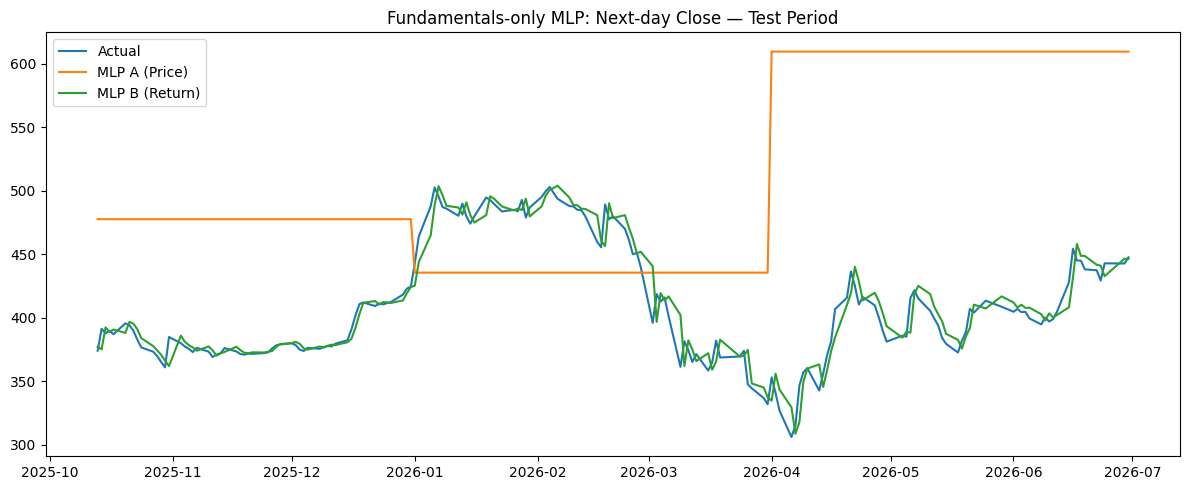

In [91]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential, layers, callbacks
from sklearn.metrics import (
    mean_absolute_error as MAE,
    mean_squared_error as MSE,
    r2_score
)

# ==========================================
# 5. METRICS
# ==========================================

def report(name, actual, predicted, previous_close):

    mae = MAE(actual, predicted)
    rmse = np.sqrt(MSE(actual, predicted))

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    r2 = r2_score(actual, predicted)

    directional_accuracy = np.mean(
        np.sign(actual - previous_close)
        ==
        np.sign(predicted - previous_close)
    ) * 100

    print(
        f"{name}: "
        f"MAE {mae:.2f} "
        f"RMSE {rmse:.2f} "
        f"MAPE {mape:.2f}% "
        f"R2 {r2:.3f} "
        f"DirAcc {directional_accuracy:.1f}%"
    )


# ==========================================
# 6. MLP MODEL
# ==========================================

def build_mlp():

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),

        layers.Dense(64, activation="relu"),

        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),

        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


# ==========================================
# 7. MODEL A — NEXT-DAY CLOSE
# ==========================================

model_price = build_mlp()

history_price = model_price.fit(
    X_train_scaled,
    y_price_train_scaled,
    validation_data=(
        X_val_scaled,
        y_price_val_scaled
    ),
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(
            patience=20,
            restore_best_weights=True
        )
    ]
)

# ==========================================
# 8. MODEL B — NEXT-DAY LOG RETURN
# ==========================================
model_return = build_mlp()

history_return = model_return.fit(
    X_train_scaled,
    y_return_train_scaled,
    validation_data=(
        X_val_scaled,
        y_return_val_scaled
    ),
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(
            patience=20,
            restore_best_weights=True
        )
    ]
)

# ==========================================
# 9. PREDICTIONS — TRAIN / VALIDATION / TEST
# ==========================================

# ---------- MODEL A: PRICE TARGET ----------

pred_price_train_scaled = model_price.predict(
    X_train_scaled,
    verbose=0
)

pred_price_val_scaled = model_price.predict(
    X_val_scaled,
    verbose=0
)

pred_price_test_scaled = model_price.predict(
    X_test_scaled,
    verbose=0
)

# Convert back to actual prices
pred_price_train = scaler_y_price.inverse_transform(
    pred_price_train_scaled
).ravel()

pred_price_val = scaler_y_price.inverse_transform(
    pred_price_val_scaled
).ravel()

pred_price_test = scaler_y_price.inverse_transform(
    pred_price_test_scaled
).ravel()


# ---------- MODEL B: LOG-RETURN TARGET ----------

pred_return_train_scaled = model_return.predict(
    X_train_scaled,
    verbose=0
)

pred_return_val_scaled = model_return.predict(
    X_val_scaled,
    verbose=0
)

pred_return_test_scaled = model_return.predict(
    X_test_scaled,
    verbose=0
)

# Convert back to actual log returns
pred_return_train = scaler_y_return.inverse_transform(
    pred_return_train_scaled
).ravel()

pred_return_val = scaler_y_return.inverse_transform(
    pred_return_val_scaled
).ravel()

pred_return_test = scaler_y_return.inverse_transform(
    pred_return_test_scaled
).ravel()


# Convert predicted log return → predicted next-day price
pred_return_price_train = (
    current_close.iloc[:train_end].values
    * np.exp(pred_return_train)
)

pred_return_price_val = (
    current_close.iloc[train_end:val_end].values
    * np.exp(pred_return_val)
)

pred_return_price_test = (
    current_close_test.values
    * np.exp(pred_return_test)
)


# ==========================================
# 10. TRAIN / VALIDATION / TEST METRICS
# ==========================================

print("\nFUNDAMENTALS-ONLY MLP — ALL SPLITS")
print("=" * 70)

# ---------- MODEL A ----------
print("\nMODEL A — NEXT-DAY CLOSE (PRICE TARGET)")
print("-" * 70)

report(
    "Train",
    y_price_train.values,
    pred_price_train,
    current_close.iloc[:train_end].values
)

report(
    "Validation",
    y_price_val.values,
    pred_price_val,
    current_close.iloc[train_end:val_end].values
)

report(
    "Test",
    y_price_test.values,
    pred_price_test,
    current_close_test.values
)


# ---------- MODEL B ----------
print("\nMODEL B — NEXT-DAY LOG RETURN")
print("-" * 70)

report(
    "Train",
    y_price_train.values,
    pred_return_price_train,
    current_close.iloc[:train_end].values
)

report(
    "Validation",
    y_price_val.values,
    pred_return_price_val,
    current_close.iloc[train_end:val_end].values
)

report(
    "Test",
    y_price_test.values,
    pred_return_price_test,
    current_close_test.values
)


# ==========================================
# 10. SAVE TEST PREDICTIONS
# ==========================================

results = pd.DataFrame({
    "DATE": target_dates.iloc[val_end:].values,
    "Actual Close": y_price_test.values,
    "MLP A (Price Target)": pred_price,
    "MLP B (Return Target)": pred_return_price
})

print("\nTest Predictions:")
print(results.head(20))

results.to_csv(
    "fundamentals_mlp_nextday_predictions.csv",
    index=False
)


# ==========================================
# 11. PLOT
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    results["DATE"],
    results["Actual Close"],
    label="Actual"
)

plt.plot(
    results["DATE"],
    results["MLP A (Price Target)"],
    label="MLP A (Price)"
)

plt.plot(
    results["DATE"],
    results["MLP B (Return Target)"],
    label="MLP B (Return)"
)

plt.legend()
plt.title(
    "Fundamentals-only MLP: Next-day Close — Test Period"
)
plt.tight_layout()
plt.show()

RAW FEATURE SCALE (X_train)
                             mean          std          min          max        range
Revenue                 41,561.68    13,045.43    25,917.00    81,244.00    55,327.00
Revenue Growth (YoY)        33.89        11.26        14.54        64.78        50.24
Net Income              11,846.30     4,724.11     2,654.00    26,043.00    23,389.00
Net Income Growth           57.67       101.18       -64.08       379.08       443.16
EPS (Basic)                  4.84         1.93         1.08        10.64         9.56
EPS (Diluted)                4.84         1.93         1.08        10.64         9.56
EPS Growth                  57.63       101.12       -64.07       378.80       442.87
Total Assets         4,340,904.00 1,933,022.03 2,481,044.00 8,069,097.00 5,588,053.00
Cash & Equivalents     191,362.64    55,957.04   109,080.00   268,961.00   159,881.00

SCALED FEATURE SCALE (X_train_scaled)
Expected: mean ≈ 0, std ≈ 1
                        mean    std     min  

/tmp/ipykernel_49/3791137631.py:145: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_49/3791137631.py:158: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


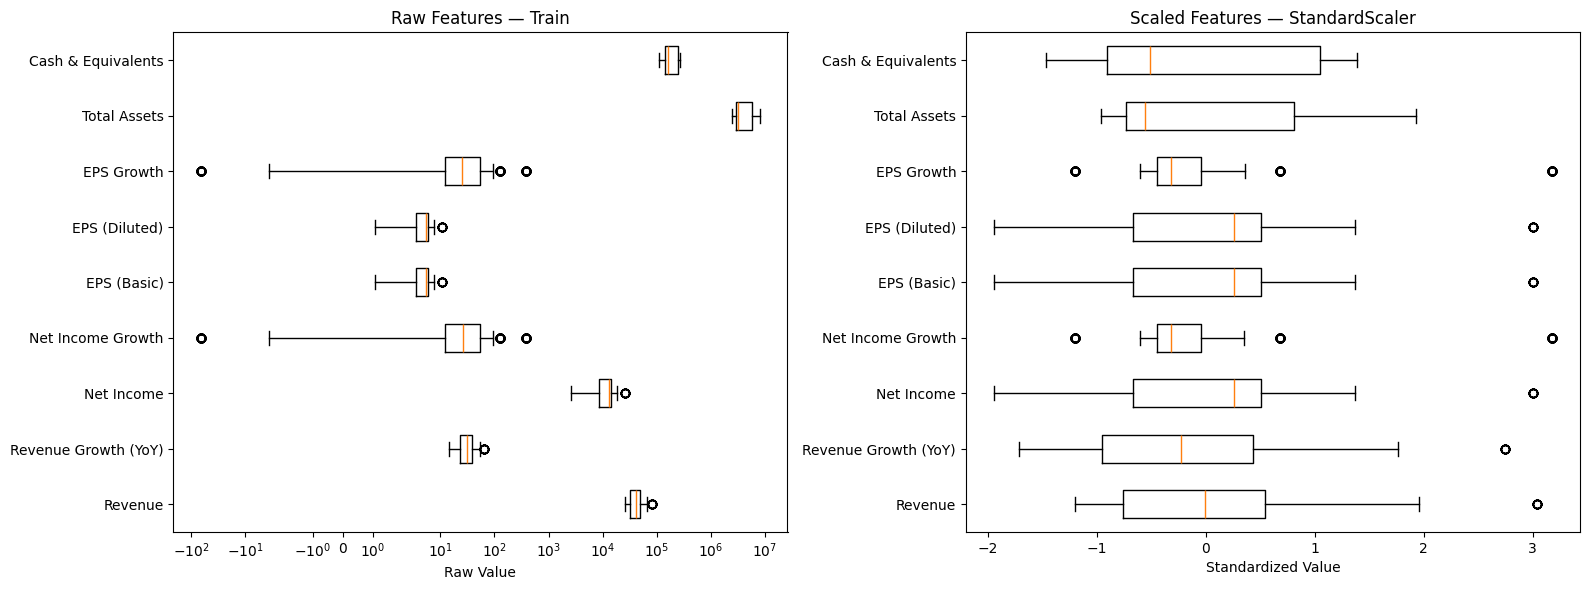

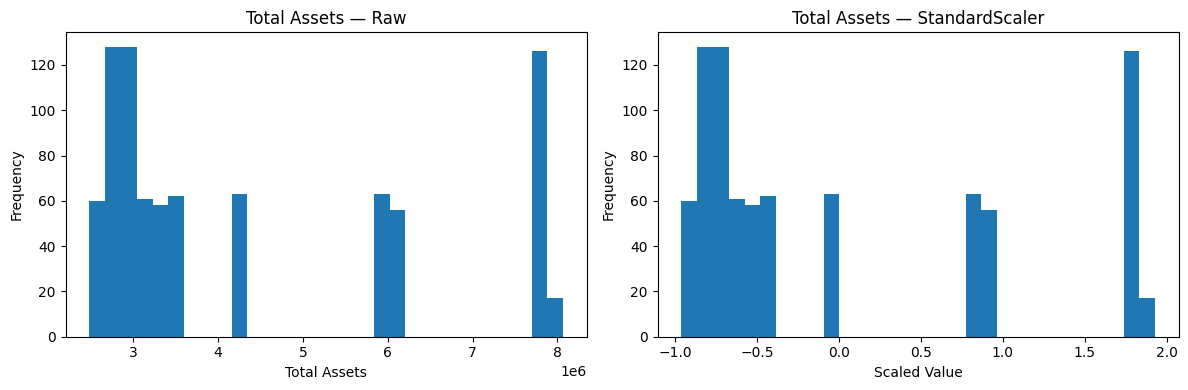

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. RAW FEATURE SCALE — TRAIN
# ==========================================

raw_stats = X_train.describe().T[
    ["mean", "std", "min", "max"]
]

raw_stats["range"] = (
    raw_stats["max"] - raw_stats["min"]
)

print("=" * 70)
print("RAW FEATURE SCALE (X_train)")
print("=" * 70)

print(
    raw_stats.to_string(
        float_format=lambda v: f"{v:,.2f}"
    )
)


# ==========================================
# 2. SCALED FEATURE SCALE — TRAIN
# ==========================================

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

scaled_stats = X_train_scaled_df.describe().T[
    ["mean", "std", "min", "max"]
]

scaled_stats["range"] = (
    scaled_stats["max"] - scaled_stats["min"]
)

print("\n" + "=" * 70)
print("SCALED FEATURE SCALE (X_train_scaled)")
print("Expected: mean ≈ 0, std ≈ 1")
print("=" * 70)

print(
    scaled_stats.to_string(
        float_format=lambda v: f"{v:,.4f}"
    )
)


# ==========================================
# 3. VALIDATION / TEST AFTER SCALING
# ==========================================

for name, arr in [
    ("X_val_scaled", X_val_scaled),
    ("X_test_scaled", X_test_scaled)
]:

    df_scaled = pd.DataFrame(
        arr,
        columns=X_train.columns
    )

    print(
        f"\n{name}: mean / std / min / max per feature"
    )

    print(
        df_scaled.describe().T[
            ["mean", "std", "min", "max"]
        ].to_string(
            float_format=lambda v: f"{v:,.2f}"
        )
    )


# ==========================================
# 4. TARGET — CLOSE BEFORE vs AFTER
# ==========================================

print("\n" + "=" * 70)
print("TARGET SCALING — NEXT-DAY CLOSE")
print("=" * 70)

print(
    "Raw y_price_train: "
    f"mean={y_price_train.mean():.2f}, "
    f"std={y_price_train.std():.2f}, "
    f"min={y_price_train.min():.2f}, "
    f"max={y_price_train.max():.2f}"
)

print(
    "Scaled y_price_train: "
    f"mean={y_price_train_scaled.mean():.4f}, "
    f"std={y_price_train_scaled.std():.4f}, "
    f"min={y_price_train_scaled.min():.4f}, "
    f"max={y_price_train_scaled.max():.4f}"
)


# ==========================================
# 5. TARGET — LOG RETURN BEFORE vs AFTER
# ==========================================

print("\n" + "=" * 70)
print("TARGET SCALING — NEXT-DAY LOG RETURN")
print("=" * 70)

print(
    "Raw y_return_train: "
    f"mean={y_return_train.mean():.6f}, "
    f"std={y_return_train.std():.6f}, "
    f"min={y_return_train.min():.6f}, "
    f"max={y_return_train.max():.6f}"
)

print(
    "Scaled y_return_train: "
    f"mean={y_return_train_scaled.mean():.4f}, "
    f"std={y_return_train_scaled.std():.4f}, "
    f"min={y_return_train_scaled.min():.4f}, "
    f"max={y_return_train_scaled.max():.4f}"
)


# ==========================================
# 6. BOXPLOTS — RAW vs SCALED FEATURES
# ==========================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

axes[0].boxplot(
    X_train.values,
    labels=X_train.columns,
    vert=False
)

axes[0].set_xscale("symlog")
axes[0].set_title(
    "Raw Features — Train"
)
axes[0].set_xlabel("Raw Value")


axes[1].boxplot(
    X_train_scaled,
    labels=X_train.columns,
    vert=False
)

axes[1].set_title(
    "Scaled Features — StandardScaler"
)
axes[1].set_xlabel("Standardized Value")


plt.tight_layout()
plt.show()


# ==========================================
# 7. ONE FEATURE — BEFORE vs AFTER
# ==========================================

col = "Total Assets"

i = list(X_train.columns).index(col)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

axes[0].hist(
    X_train[col],
    bins=30
)

axes[0].set_title(
    f"{col} — Raw"
)

axes[0].set_xlabel(col)
axes[0].set_ylabel("Frequency")


axes[1].hist(
    X_train_scaled[:, i],
    bins=30
)

axes[1].set_title(
    f"{col} — StandardScaler"
)

axes[1].set_xlabel("Scaled Value")
axes[1].set_ylabel("Frequency")


plt.tight_layout()
plt.show()